# Aufgabe 1

Bei Aufgabe 1 war es die Aufgabe die Entladung eines Kondensators im RC Kreis für 5 verschiedene Widerstände zu messen. Die Schaltung sah wie folgt aus:
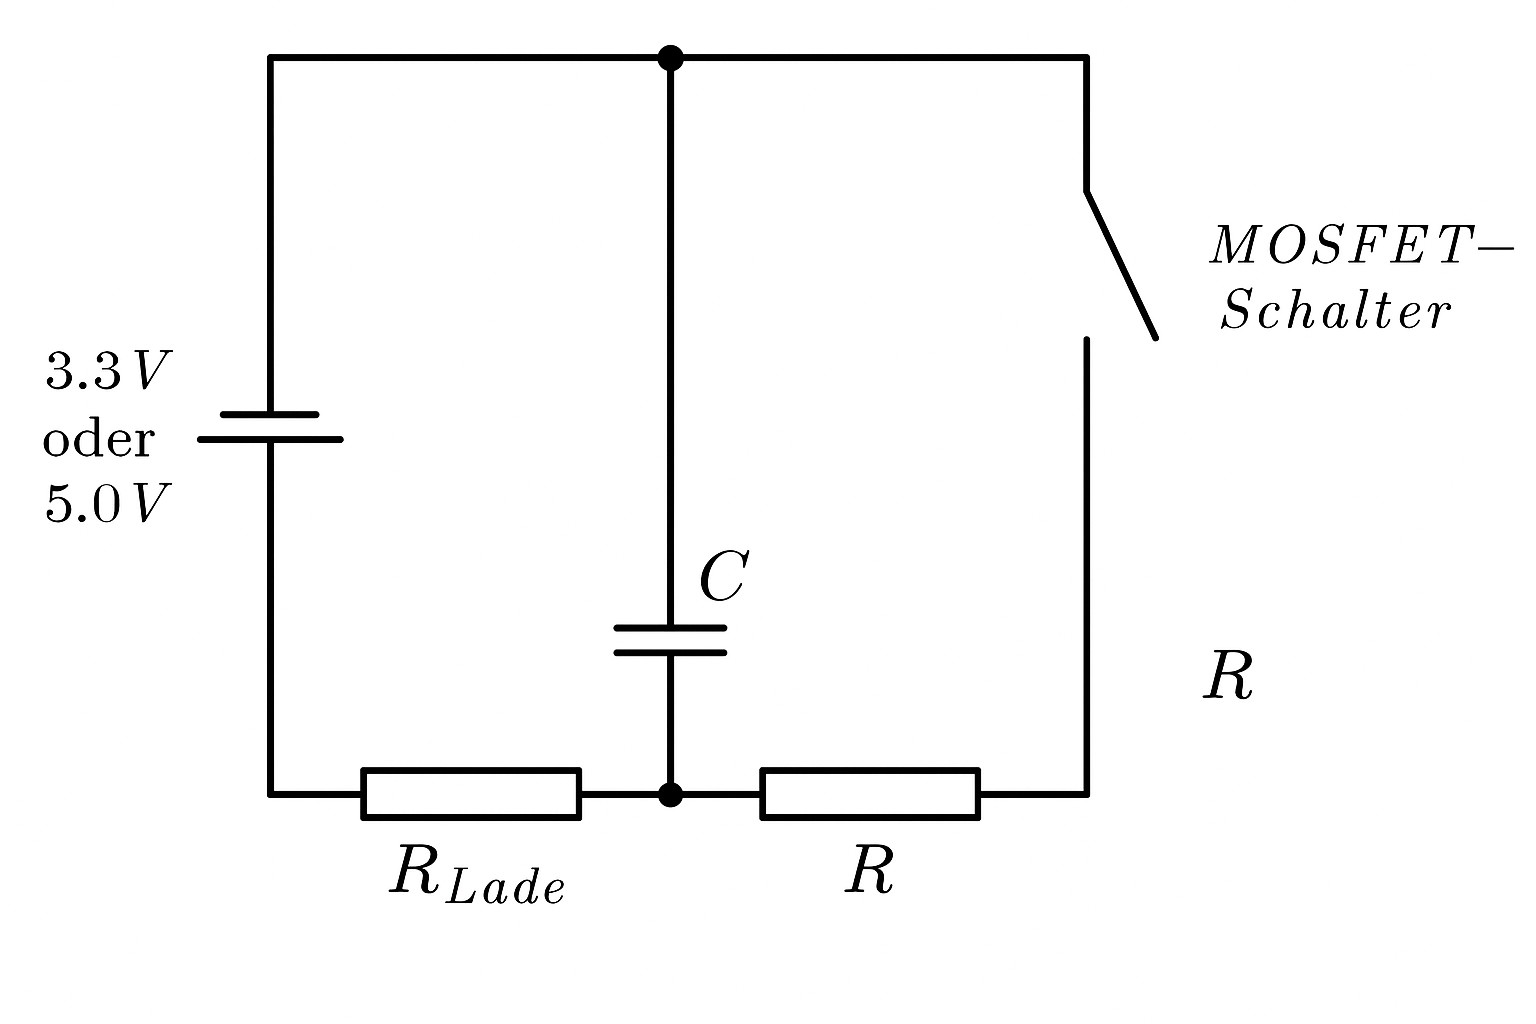

Der Widerstand $R_{lade}$ blieb dafür die ganze Zeit gleich und R wurde ausgetauscht. Genutzt haben wir dafür $R_{lade} = 986 \Omega$ und für $R$:
|Messung |R[$\Omega$]|
| ------------------------------------------- | --------------------------------------- |
| 1                            | 1,3                            | 
| 2                            | 10                              | 
| 3                           | 99,2                              | 
| 4                           | 217,3                               | 
| 5                            | 989                              | 

Der Arduino hat in der Schaltung in den gleichen Zeitabständen immer wieder den MOSFET-Schalter geschaltet und das Picoscope hat die Spannung über den Kondensator gemessen. Durch die immer gleichen Zeitabstände konnte das Programm "Picoscope 7" die Kurve mit richtig gewähltem Trigger gut anzeigen und die Werte dann exportiert werden.

# Auswertung der RC Entladung

## 1. Was wurde gemessen?

Wir haben einen Kondensator, der sich über einen Widerstand entlädt.  
Für 5 verschiedene Lastwiderstände $R_\text{last}$ wurde die Kondensatorspannung $U_C(t)$ aufgenommen.

## 2. Form der Entladung

Die Entladung eines RC Glieds folgt näherungsweise einem Exponentialgesetz:

$$
U_C(t) = U_\text{min} + \bigl(U_\text{max} - U_\text{min}\bigr) 
\exp\left(-\frac{t - t_0}{\tau}\right)
$$

- $U_\text{max}$: Spannung im oberen Plateau vor der Entladung  
- $U_\text{min}$: Spannung im unteren Plateau nach der Entladung  
- $t_0$: effektiver Startzeitpunkt der Entladung  
- $\tau$: Zeitkonstante der Schaltung  

Für jedes $R_\text{last}$ wird eine eigene Kurve aufgenommen und gefittet.

## 3. Wie wird $\tau$ aus den Messdaten bestimmt?

1. $U_\text{max}$ wird aus den ersten Messpunkten (oberes Plateau) als Median bestimmt.  
2. $U_\text{min}$ wird aus den letzten Messpunkten (unteres Plateau) als Median bestimmt.  
3. Die Spannung wird auf den Bereich 0 bis 1 normiert:

$$
u_\text{norm}(t) = \frac{U_C(t) - U_\text{min}}{U_\text{max} - U_\text{min}}
$$

4. Es werden nur die Punkte verwendet, für die ungefähr $0{,}1 < u_\text{norm} < 0{,}9$ gilt. So fallen die Plateaus am Anfang und Ende weg und es bleibt der exponentielle Teil.  
5. Für diesen Bereich gilt:

$$
u_\text{norm}(t) = \exp\left(-\frac{t - t_0}{\tau}\right)
$$

Logarithmieren:

$$
\ln u_\text{norm}(t) = -\frac{1}{\tau} t + \frac{t_0}{\tau}
$$

Das ist eine Gerade in $t$. Aus der Steigung $b$ der Ausgleichsgeraden

$$
\ln u_\text{norm}(t) = a + b t
$$

folgt

$$
\tau = -\frac{1}{b}
$$

Diese $\tau$ wird im Programm für jede der 5 Entladungen bestimmt.  
Der Fit wird im Plot nur in dem Bereich gezeigt, in dem er nicht über $U_\text{max}$ hinausgeht, damit die Messpunkte gut sichtbar bleiben.

## 4. Bestimmung der Kapazität

Für ein RC Glied gilt

$$
\tau = R_\text{last} \cdot C
$$

Daraus folgt für die experimentelle Kapazität:

$$
C_\text{exp} = \frac{\tau}{R_\text{last}}
$$

Für jeden Lastwiderstand bekommen wir so einen Wert für $C_\text{exp}$.

## 5. Impedanz des RC Glieds

Im Frequenzbereich beschreibt man das Verhalten mit der komplexen Impedanz.

- Ohmscher Widerstand:
  $
  Z_R = R_\text{last}
  $
- Kondensator:
  $
  Z_C = \frac{1}{j \omega C_\text{exp}} 
  \quad\text{mit}\quad \omega = 2 \pi f
  $

In Reihe gilt:

$$
Z(\omega) = Z_R + Z_C
$$

Im Skript wird eine feste Frequenz $f_0$ vorgegeben (Messfrequenz).  
Für diese Frequenz wird zuerst

$$
\omega_0 = 2 \pi f_0
$$

berechnet und dann

$$
Z(f_0) = R_\text{last} + \frac{1}{j \omega_0 C_\text{exp}}
$$

Der Betrag der Impedanz ist

$$
\lvert Z(f_0) \rvert = \sqrt{\Re(Z)^2 + \Im(Z)^2}
$$

und wird im Skript als $|Z(f_0)|$ ausgegeben.

## 6. Phasenverschiebung

Die Phasenverschiebung $\varphi$ zwischen Spannung und Strom ergibt sich aus dem Argument der komplexen Impedanz:

$$
\varphi(f_0) = \arg Z(f_0)
$$

Im Programm wird $\varphi$ sowohl in Radiant als auch in Grad berechnet:

$$
\varphi_\text{rad} = \arg Z(f_0)
$$
$$
\varphi_\text{deg} = \varphi_\text{rad} \cdot \frac{180^\circ}{\pi}
$$

Diese beiden Größen $|Z(f_0)|$ und $\varphi(f_0)$ werden am Ende für alle 5 Widerstände in einer Tabelle ausgegeben.


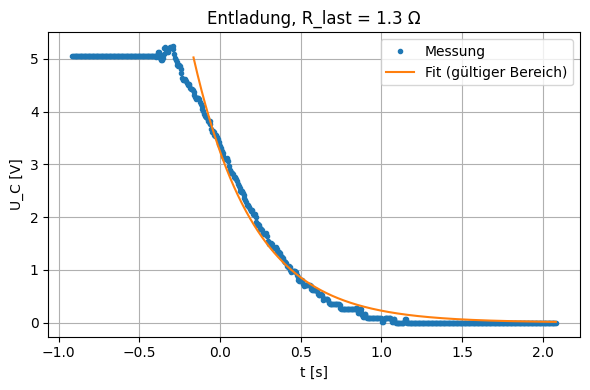

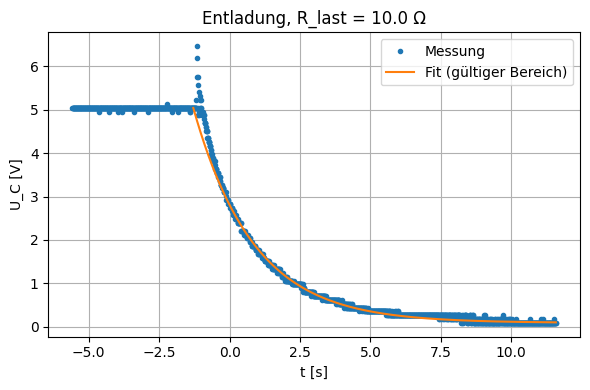

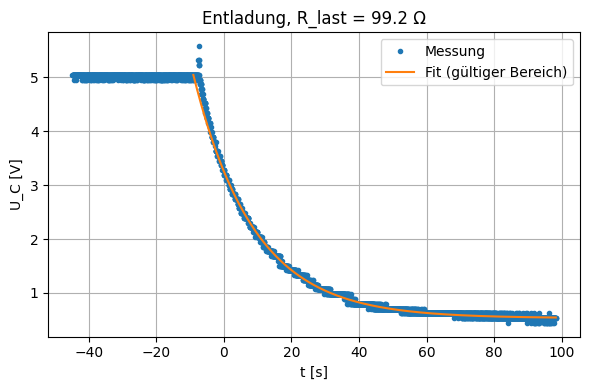

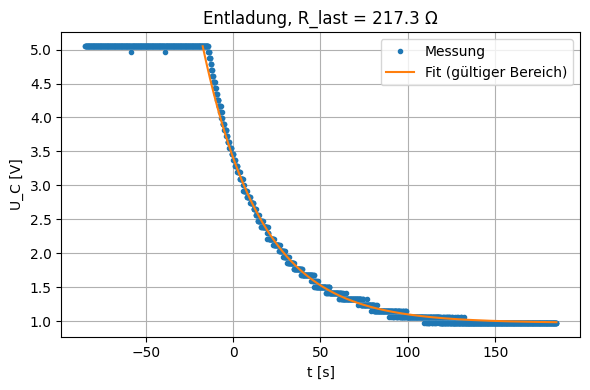

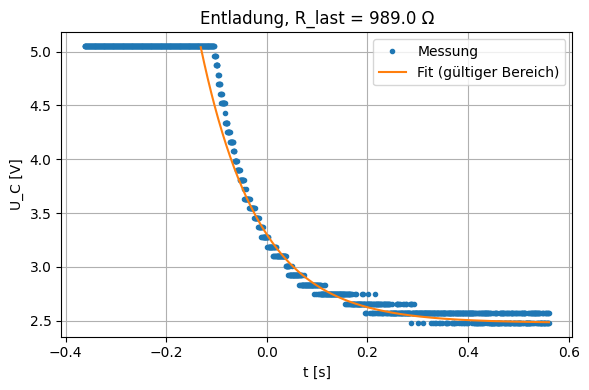

Berechnet bei f0 = 100.0 Hz

 R_last [Ohm]  |Z(f0)| [Ohm]  phi(f0) [rad]  phi(f0) [deg]
          1.3            1.3       -0.00425         -0.243
           10             10      -0.000742        -0.0425
         99.2           99.2      -8.89e-05        -0.0051
          217            217      -4.72e-05        -0.0027
          989            989        -0.0138         -0.789


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Einstellungen
# ---------------------------------------------------

# Lade-Widerstand (wird hier nur der Vollständigkeit halber notiert)
R_lade = 986.0  # Ohm

# Zuordnung: Lastwiderstand -> Messdatei
# Wenn die Dateinamen anders sind, hier anpassen!
R_last = {
    1.3:   "Messwerte/Aufgabe1_1R.csv",
    10.0:  "Messwerte/Aufgabe1_10R.csv",
    99.2:  "Messwerte/Aufgabe1_100R.csv",
    217.3: "Messwerte/Aufgabe1_220R.csv",
    989.0: "Messwerte/Aufgabe1_1000R.csv",
}


# Frequenz, bei der Impedanz und Phasenverschiebung berechnet werden sollen
f0 = 100.0  # Hz  <--- hier deine Versuchsfrequenz eintragen
omega0 = 2.0 * np.pi * f0


# ---------------------------------------------------
# Hilfsfunktionen
# ---------------------------------------------------

def lade_messung(dateiname):
    """CSV-Datei einlesen und auf Spaltennamen 'Time' und 'U' bringen."""
    df = pd.read_csv(dateiname)
    if "Channel A" in df.columns:
        df = df.rename(columns={"Channel A": "U"})
    if "Time" not in df.columns or "U" not in df.columns:
        raise ValueError("CSV muss Spalten 'Time' und 'Channel A' bzw. 'U' enthalten.")
    return df


def bestimme_tau(df):
    """
    Zeitkonstante tau aus der Entladung bestimmen:
    - U_max aus den ersten Messpunkten (Plateau),
    - U_min aus den letzten Messpunkten,
    - Normierung 0..1,
    - nur Bereich 0.1..0.9 nehmen,
    - ln(U_norm) linear fitten.
    """
    t = df["Time"].values
    u = df["U"].values

    n = len(u)
    k = max(10, n // 20)  # ca. 5% der Punkte

    U_max = np.median(u[:k])
    U_min = np.median(u[-k:])

    # zur Sicherheit tauschen, falls Messung invertiert wäre
    if U_min > U_max:
        U_min, U_max = U_max, U_min

    # Normierung auf [0,1]
    u_norm = (u - U_min) / (U_max - U_min + 1e-12)

    # nur mittlerer Entladebereich
    mask = (u_norm > 0.1) & (u_norm < 0.9)
    t_fit = t[mask]
    u_fit = u_norm[mask]

    # nur positive Werte für ln
    pos_mask = u_fit > 0
    t_fit = t_fit[pos_mask]
    u_fit = u_fit[pos_mask]

    if t_fit.size < 2:
        raise RuntimeError("Zu wenige Punkte im Entladebereich für den Fit.")

    y = np.log(u_fit)
    A = np.vstack([np.ones_like(t_fit), t_fit]).T
    (a, b), *_ = np.linalg.lstsq(A, y, rcond=None)

    tau = -1.0 / b
    t0 = a * tau

    return U_max, U_min, t0, tau


# ---------------------------------------------------
# Auswertung: Entladekurven + Impedanz / Phase
# ---------------------------------------------------

ergebnisse = []

for R, fname in R_last.items():
    df = lade_messung(fname)
    U_max, U_min, t0, tau = bestimme_tau(df)

    t = df["Time"].values
    u = df["U"].values

    # Zeitfenster um die eigentliche Entladung
    t_mask = (t > t0 - 2 * tau) & (t < t0 + 6 * tau)
    t_win = t[t_mask]
    u_win = u[t_mask]

    # vollständiger Fit über dieses Zeitfenster
    u_fit_full = U_min + (U_max - U_min) * np.exp(-(t_win - t0) / tau)

    # Fit nur dort zeigen, wo er U_max nicht übersteigt
    fit_mask = u_fit_full <= U_max + 1e-9
    t_fit_plot = t_win[fit_mask]
    u_fit_plot = u_fit_full[fit_mask]

    # Plot: einzelne Entladung
    plt.figure(figsize=(6, 4))
    plt.plot(t_win, u_win, ".", label="Messung")
    plt.plot(t_fit_plot, u_fit_plot, "-", label="Fit (gültiger Bereich)")
    plt.xlabel("t [s]")
    plt.ylabel("U_C [V]")
    plt.title(f"Entladung, R_last = {R} Ω")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # --------------------------------------
    # Impedanz & Phasenverschiebung bei f0
    # --------------------------------------
    # experimentelle Kapazität aus tau = R * C
    C_exp = tau / R

    # komplexe Impedanz Z = R + 1/(j ω C)
    Z = R + 1.0 / (1j * omega0 * C_exp)
    Z_abs = np.abs(Z)
    phi_rad = np.angle(Z)
    phi_deg = np.degrees(phi_rad)

    ergebnisse.append(
        {
            "R_last [Ohm]": R,
            "|Z(f0)| [Ohm]": Z_abs,
            "phi(f0) [rad]": phi_rad,
            "phi(f0) [deg]": phi_deg,
        }
    )

# alle Plots anzeigen
plt.show()

# ---------------------------------------------------
# Ausgabe NUR: Impedanz und Phasenverschiebung
# ---------------------------------------------------

ergebnisse_df = pd.DataFrame(ergebnisse)
print(f"Berechnet bei f0 = {f0} Hz\n")
print(
    ergebnisse_df.to_string(
        index=False,
        float_format=lambda x: f"{x:8.3g}"
    )
)
